<a href="https://colab.research.google.com/github/sajid-shahriar/pytorch-tutorial/blob/main/ltb_dataset_and_dataloaders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt

import random

In [6]:
training_data = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.72MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 28.0MB/s]


In [7]:
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)


In [8]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

In [9]:
dummy_image, dummy_label = training_data[0]

print(f"dummy_image shape: {dummy_image.shape}")
print(f"dummy_image_type: {dummy_image.dtype}")
# print(f"dummy_image: \n{dummy_image}\n")

print(f"dummy_label datatype: {type(dummy_label)}")
print(f"dummy_label value: {dummy_label}")

dummy_image shape: torch.Size([1, 28, 28])
dummy_image_type: torch.float32
dummy_label datatype: <class 'int'>
dummy_label value: 9


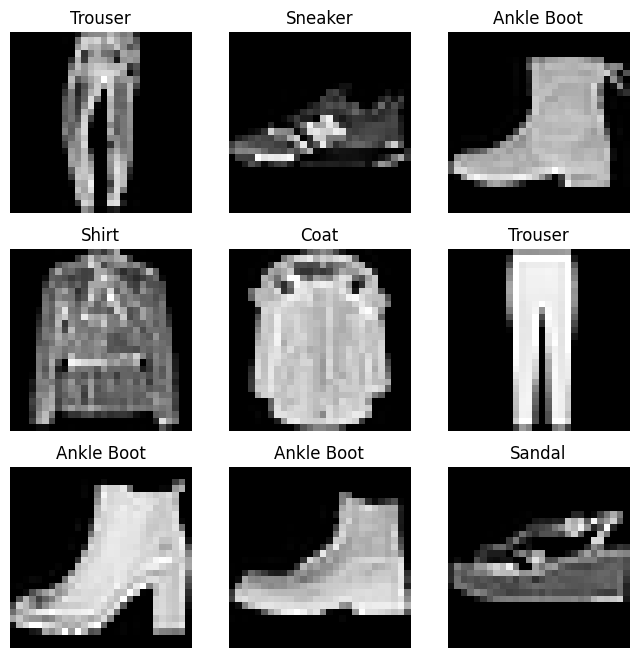

In [10]:
# Creates an empty main canvas window that is 8 inches wide by 8 inches high
figure = plt.figure(figsize=(8,8))

# Sets up grid dimensions: 3 rows and 3 columns = 9 plots total
cols, rows = 3, 3

# Loop 9 times (1 to 9 inclusive). Matplotlib subplots use 1-based indexing!
for i in range(1, cols* rows + 1):
  sample_idx = random.randint(0, len(training_data) -1)
  image, label = training_data[sample_idx]
  # Allocate cell 'i' out of the 3x3 grid on the main figure canvas
  figure.add_subplot(rows, cols, i)
  plt.title(labels_map[label])
  # Remove axis numbers, ticks, and border frames for a clean image view
  plt.axis("off")
  plt.imshow(image.squeeze(), cmap="gray")

#Creating a custom dataset

A custom Dataset class must implement three functions: __\_\_init\_\___, __\_\_len\_\___, and __\_\_getitem\_\___.

The following implementation is of the dataset FashionMNIST if it were not used from the datasets class.In this situation, the FashionMNIST images are stored in a directory image_dir, and their labels are stored separately in a CSV file annotations_file.


In [11]:
import os
import pandas as pd
from torchvision.io import decode_image

In [12]:
class CustomImageDataset(Dataset):
  def __init__(self, annotations_file, image_dir, transform=None, target_transform=None):
    self.image_labels = pd.read_csv(annotations_file)
    self.image_dir = image_dir
    self.transform = transform
    self.target_transform = target_transform

  def __len__(self):
    return len(self.image_labels)

  def __getitem__(self, index):
    '''
      iloc() stands for integer location. the image_labels
      dataframe has rows and columns iloc(row, column) provides
      the value in the specific cell.
    '''
    image_path = os.path.join(self.image_dir, self.image_labels.iloc[index,0])
    '''
      decode_image -> Decode an image into a uint8 tensor, from a path or from raw encoded bytes.
    '''
    image = decode_image(image_path)
    label = self.image_labels.iloc[index, 1]

    if self.transform:
      image = self.transform(image)

    if self.target_transform:
      label = self.target_transform(label)


    return image, label


#Preparing data for training with dataloaders

The Dataset retrieves our dataset’s features and labels one sample at a time. While training a model, we typically want to pass samples in “minibatches”, reshuffle the data at every epoch to reduce model overfitting, and use Python’s multiprocessing to speed up data retrieval.

DataLoader is an iterable that abstracts this complexity for us in an easy API.

In [13]:
from torch.utils.data import DataLoader

In [14]:
train_dataloader = DataLoader(
    training_data,
    batch_size = 64,
    shuffle = True
)

In [15]:
test_dataloader = DataLoader(
    test_data,
    batch_size = 64,
    shuffle = True
)

Feature batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


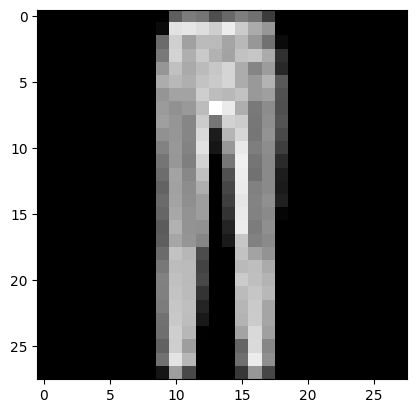

Label: Trouser


In [20]:
train_features, train_labels = next(iter(train_dataloader))

print(f"Feature batch shape: {train_features.size()}")
print(f"Label batch shape: {train_labels.size()}")

image = train_features[0]
label = train_labels[0]

plt.imshow(image.squeeze(), cmap="gray")
plt.show()
print(f"Label: {labels_map[label.item()]}")